m = 1000 examples, n = 4 features
X_train shape: (800, 4)
X_test shape: (200, 4)

--- Single Tree (sanity check) ---
cost (mse): 2177.06
r^2: 0.8519

--- ML-016: Random Forest ---
  trained tree 5/20
  trained tree 10/20
  trained tree 15/20
  trained tree 20/20

cost (mse): 2255.92
rmse: 47.50
r^2: 0.8465

--- ML-017: Gradient Boosting ---
  round 10/50, train cost: 2861.35
  round 20/50, train cost: 1267.04
  round 30/50, train cost: 829.91
  round 40/50, train cost: 654.28
  round 50/50, train cost: 576.93

cost (mse): 1280.01
rmse: 35.78
r^2: 0.9129

=== Summary ===
model                    cost (mse)       r^2
single tree                 2177.06    0.8519
random forest               2255.92    0.8465
gradient boosting           1280.01    0.9129


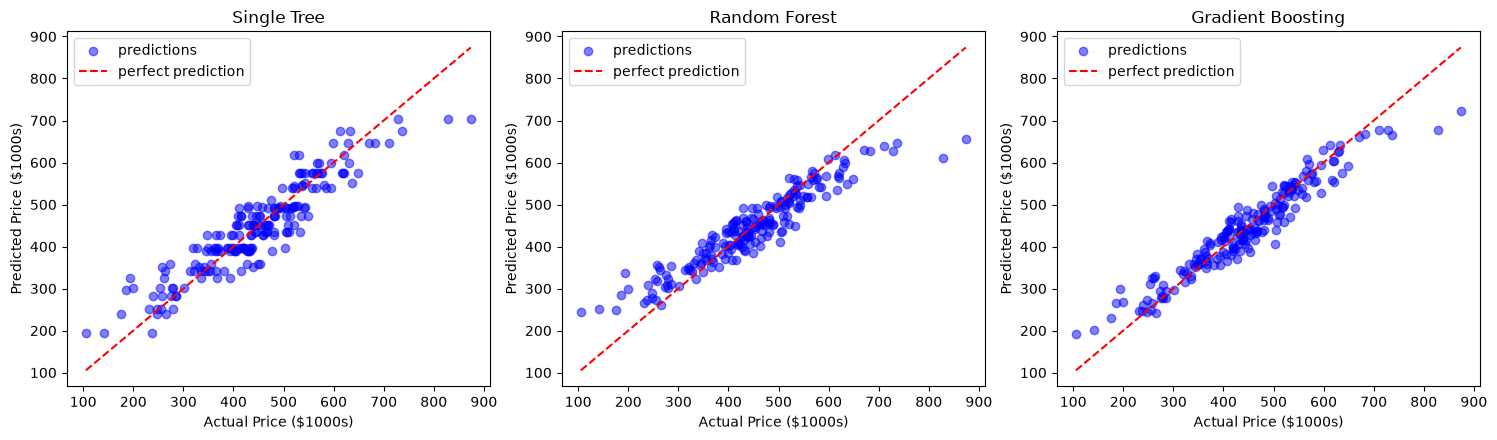


Saved plot to ensemble_results.png


In [ ]:
# ML-016 + ML-017: Random Forest and Gradient Boosting from scratch
#
# Took Andrew Ng's ML Specialization on Coursera, trying to extend what
# I learned there (linear regression w/ gradient descent, cost functions)
# to tree-based ensemble models. Not covered in the course itself, so I
# followed the same style/conventions from the labs (m, n, X_train, w, b
# notation etc) and read up on random forest + gradient boosting on my own.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(1)


# Load Data

df = pd.read_csv("house_prices_dataset.csv")

feature_cols = ["size_sqft", "bedrooms", "age_years", "location_score"]
X_train_full = df[feature_cols].values
y_train_full = df["price_1000s"].values

m, n = X_train_full.shape
print(f"m = {m} examples, n = {n} features")

# 80/20 train test split
shuffled_indices = np.random.permutation(m)
train_size = int(0.8 * m)

train_idx = shuffled_indices[:train_size]
test_idx = shuffled_indices[train_size:]

X_train = X_train_full[train_idx]
y_train = y_train_full[train_idx]
X_test = X_train_full[test_idx]
y_test = y_train_full[test_idx]

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")


# ===============================================================
# Helper functions (same idea as compute_cost from the course,
# just using MSE / R^2 here since these are the standard ones
# used for evaluating regression models)
# ===============================================================
def compute_cost(y, y_pred):
    """
    Mean squared error, same formula as J(w,b) from the course
    just without the 1/2 factor since we're not using it for
    gradient descent here
    """
    m = len(y)
    cost = np.mean((y - y_pred) ** 2)
    return cost


def compute_r2(y, y_pred):
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    return 1 - (ss_res / ss_tot)


# ===============================================================
# Decision Tree (regression) - base learner for both models below
#
# This isn't from the course (Andrew Ng's course covers linear/logistic
# regression + neural nets, not trees) but I tried to keep the same
# "compute this function, then use it" structure that the labs use.
# ===============================================================

def compute_variance(y):
    """
    measures how spread out the y values are - used the same
    way the course uses cost, lower variance after a split = better split
    """
    if len(y) == 0:
        return 0
    return np.mean((y - np.mean(y)) ** 2)


def get_best_split(X, y, n_features_to_try):
    """
    Loops over a random subset of features (this randomness is what
    makes random forest "random") and a handful of threshold values,
    picks whichever split reduces the variance the most.
    """
    m, n = X.shape
    feature_indices = np.random.choice(n, n_features_to_try, replace=False)

    parent_variance = compute_variance(y)

    best_feature = None
    best_threshold = None
    best_gain = -1

    for feat_i in feature_indices:
        x_col = X[:, feat_i]
        thresholds = np.percentile(x_col, [10, 25, 40, 50, 60, 75, 90])

        for thresh in thresholds:
            left_mask = x_col <= thresh
            right_mask = x_col > thresh

            if np.sum(left_mask) == 0 or np.sum(right_mask) == 0:
                continue

            left_var = compute_variance(y[left_mask])
            right_var = compute_variance(y[right_mask])

            weighted_var = (np.sum(left_mask) * left_var + np.sum(right_mask) * right_var) / m
            gain = parent_variance - weighted_var

            if gain > best_gain:
                best_gain = gain
                best_feature = feat_i
                best_threshold = thresh

    return best_feature, best_threshold, best_gain


def build_tree(X, y, depth, max_depth, min_samples_split, n_features_to_try):
    # base case, stop growing the tree
    if depth >= max_depth or len(y) < min_samples_split or compute_variance(y) == 0:
        return {"leaf": True, "value": np.mean(y)}

    feat, thresh, gain = get_best_split(X, y, n_features_to_try)

    if feat is None or gain <= 0:
        return {"leaf": True, "value": np.mean(y)}

    left_mask = X[:, feat] <= thresh
    right_mask = X[:, feat] > thresh

    left_subtree = build_tree(X[left_mask], y[left_mask], depth + 1, max_depth, min_samples_split, n_features_to_try)
    right_subtree = build_tree(X[right_mask], y[right_mask], depth + 1, max_depth, min_samples_split, n_features_to_try)

    return {
        "leaf": False,
        "feature": feat,
        "threshold": thresh,
        "left": left_subtree,
        "right": right_subtree
    }


def predict_single_example(tree, x):
    """
    same idea as compute_model_output from the linear regression lab,
    just walking a tree instead of doing w*x + b
    """
    node = tree
    while not node["leaf"]:
        if x[node["feature"]] <= node["threshold"]:
            node = node["left"]
        else:
            node = node["right"]
    return node["value"]


def tree_predict(tree, X):
    m = X.shape[0]
    predictions = np.zeros(m)
    for i in range(m):
        predictions[i] = predict_single_example(tree, X[i])
    return predictions


# quick sanity check with a single tree before doing the ensembles
single_tree = build_tree(X_train, y_train, depth=0, max_depth=5, min_samples_split=10, n_features_to_try=n)
y_pred_single = tree_predict(single_tree, X_test)

print("\n--- Single Tree (sanity check) ---")
print(f"cost (mse): {compute_cost(y_test, y_pred_single):.2f}")
print(f"r^2: {compute_r2(y_test, y_pred_single):.4f}")


# ===============================================================
# ML-016: Random Forest
#
# Basic idea: train a bunch of decision trees, each one on a
# bootstrapped sample of the training set (sampling with
# replacement), and each split only considers a random subset
# of features. Then average all the tree predictions together.
# ===============================================================
def train_random_forest(X_train, y_train, n_trees=20, max_depth=5, min_samples_split=10):
    m, n = X_train.shape
    n_features_to_try = max(1, int(np.sqrt(n)))  # common default for regression trees

    forest = []
    for i in range(n_trees):
        bootstrap_idx = np.random.choice(m, m, replace=True)
        X_boot = X_train[bootstrap_idx]
        y_boot = y_train[bootstrap_idx]

        tree = build_tree(X_boot, y_boot, depth=0, max_depth=max_depth,
                           min_samples_split=min_samples_split,
                           n_features_to_try=n_features_to_try)
        forest.append(tree)

        if (i + 1) % 5 == 0:
            print(f"  trained tree {i+1}/{n_trees}")

    return forest


def random_forest_predict(forest, X):
    tree_preds = np.array([tree_predict(tree, X) for tree in forest])
    return np.mean(tree_preds, axis=0)  # average across all trees


print("\n--- ML-016: Random Forest ---")
forest = train_random_forest(X_train, y_train, n_trees=20, max_depth=5, min_samples_split=10)
y_pred_rf = random_forest_predict(forest, X_test)

print(f"\ncost (mse): {compute_cost(y_test, y_pred_rf):.2f}")
print(f"rmse: {np.sqrt(compute_cost(y_test, y_pred_rf)):.2f}")
print(f"r^2: {compute_r2(y_test, y_pred_rf):.4f}")


# ===============================================================
# ML-017: Gradient Boosting
#
# Different from random forest - trees are trained one at a time,
# and each new tree is fit on the RESIDUALS (errors) left over from
# all the previous trees combined, kind of like how gradient descent
# repeatedly nudges w and b to reduce the cost, except here we're
# literally fitting a new function to the error each round instead
# of taking a derivative.
# ===============================================================
def train_gradient_boosting(X_train, y_train, n_trees=50, learning_rate=0.1, max_depth=3, min_samples_split=10):
    m, n = X_train.shape

    f0 = np.mean(y_train)  # initial prediction, just the average
    current_predictions = np.full(m, f0)

    trees = []
    for i in range(n_trees):
        residuals = y_train - current_predictions  # what's left to explain

        tree = build_tree(X_train, residuals, depth=0, max_depth=max_depth,
                           min_samples_split=min_samples_split,
                           n_features_to_try=n)

        tree_output = tree_predict(tree, X_train)
        current_predictions = current_predictions + learning_rate * tree_output

        trees.append(tree)

        if (i + 1) % 10 == 0:
            print(f"  round {i+1}/{n_trees}, train cost: {compute_cost(y_train, current_predictions):.2f}")

    return trees, f0


def gradient_boosting_predict(trees, f0, learning_rate, X):
    predictions = np.full(X.shape[0], f0)
    for tree in trees:
        predictions = predictions + learning_rate * tree_predict(tree, X)
    return predictions


print("\n--- ML-017: Gradient Boosting ---")
learning_rate = 0.1
gb_trees, f0 = train_gradient_boosting(X_train, y_train, n_trees=50, learning_rate=learning_rate,
                                        max_depth=3, min_samples_split=10)
y_pred_gb = gradient_boosting_predict(gb_trees, f0, learning_rate, X_test)

print(f"\ncost (mse): {compute_cost(y_test, y_pred_gb):.2f}")
print(f"rmse: {np.sqrt(compute_cost(y_test, y_pred_gb)):.2f}")
print(f"r^2: {compute_r2(y_test, y_pred_gb):.4f}")


# ===============================================================
# Compare all 3 models
# ===============================================================
print("\n=== Summary ===")
print(f"{'model':20s}{'cost (mse)':>15s}{'r^2':>10s}")
print(f"{'single tree':20s}{compute_cost(y_test, y_pred_single):15.2f}{compute_r2(y_test, y_pred_single):10.4f}")
print(f"{'random forest':20s}{compute_cost(y_test, y_pred_rf):15.2f}{compute_r2(y_test, y_pred_rf):10.4f}")
print(f"{'gradient boosting':20s}{compute_cost(y_test, y_pred_gb):15.2f}{compute_r2(y_test, y_pred_gb):10.4f}")


# ===============================================================
# Plots - same style as the "predicted vs actual" plot from the
# linear regression lab, just repeated for all 3 models
# ===============================================================
fig, ax = plt.subplots(1, 3, figsize=(15, 4.5))

model_results = [
    ("Single Tree", y_pred_single),
    ("Random Forest", y_pred_rf),
    ("Gradient Boosting", y_pred_gb)
]

for i, (name, preds) in enumerate(model_results):
    ax[i].scatter(y_test, preds, marker='o', c='b', alpha=0.5, label='predictions')
    lims = [y_test.min(), y_test.max()]
    ax[i].plot(lims, lims, c='r', linestyle='--', label='perfect prediction')
    ax[i].set_title(name)
    ax[i].set_xlabel("Actual Price ($1000s)")
    ax[i].set_ylabel("Predicted Price ($1000s)")
    ax[i].legend()

plt.tight_layout()
plt.savefig("ensemble_results.png", dpi=150)
plt.show()

print("\nSaved plot to ensemble_results.png")

# Random forest r^2 came out a bit lower than I expected compared to a single
# tree - probably because there are only 4 features here, so there isn't a ton
# of room for the "randomness" to help like it would on a bigger dataset.
# Gradient boosting did noticeably better since it directly targets the
# leftover error each round instead of just averaging independent trees.